<table>
  <tr>
    <td><div align="left"><font size="30">Robotics Toolbox</font></div></td>
    <td><img src="https://raw.github.com/petercorke/robotics-toolbox-python/master/docs/figs/RobToolBox_RoundLogoB.png" width="300"></td>
  </tr>
</table>

(c) Peter Corke 2026

In [ ]:
import importlib
import setup_tutorial
importlib.reload(setup_tutorial)
await setup_tutorial.setup_tutorial(required_toolboxes=['roboticstoolbox', 'pgraph'], required_packages=['matplotlib', 'numpy', 'scipy'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
np.set_printoptions(linewidth=100, formatter={'float': lambda x: f"{x:10.4g}" if abs(x) > 1e-10 else f"{0:10.4g}"})

# A simple example


In [1]:
import roboticstoolbox as rtb
from roboticstoolbox import models, jtraj
from roboticstoolbox.tools.trajectory import jtraj
import json
import math
from spatialmath import Polygon2


# Mobile robotics

In [ ]:
veh = rtb.Bicycle(steer_max=1, L=2, workspace=10)
print(veh.curvature_max)

print(veh.x)
xd = veh.deriv(u=(1, 0.2), x= [0,0,0])
print(xd)

In [ ]:
veh.run(10, control=lambda v, t, x: (1, 0.5 if 1<t<2 else 0), animate=True)

In [ ]:
from pgraph import UGraph

with open(rtb.rtb_path_to_datafile('data/queensland.json'), 'r') as f:
    data = json.loads(f.read())
g = UGraph()
for name, info in data['places'].items():
    g.add_vertex(name=name, coord=info["utm"]) # add places as vertices
for route in data['routes']:
    g.add_edge(route['start'], route['end'], cost=route['distance']) # add routes as edges

g.plot()



In [ ]:
path, length, parents = g.path_Astar('Hughenden', 'Brisbane')

g.plot(block=None)
g.highlight_path(path)

# occupancy grid path planning

In [ ]:
house = rtb.rtb_load_matfile('data/house.mat')
floorplan = house['floorplan']
places = house['places']

pmarker = dict(markersize=6, color='y')
dx = rtb.DistanceTransformPlanner(floorplan, inflate=5)
dx.plan(places.kitchen)
dx.plot()

In [ ]:
p = dx.query(places.br3)

dx.plot(p, inflated=True, path_marker=pmarker)


# PRM

In [ ]:
house = rtb.rtb_load_matfile('data/house.mat')
floorplan = house['floorplan']
places = house['places']

prm = rtb.PRMPlanner(occgrid=floorplan, seed=0)
prm.plan(npoints=50)

prm.plot(edge=dict(alpha=0.3), vertex=dict(alpha=0.3))
print(prm)



In [ ]:
# reseed the PRN to get a workable solution
# prm = PRMPlanner(occgrid=floorplan, seed=2)
prm.plan(npoints=200)
prm.plot(edge=dict(alpha=0.1), vertex=dict(alpha=0.1))
print(prm)

# Planning with motion constraints

## Dubbins paths

In [ ]:
qs = (0, 0, math.pi/2)
qg = (1, 0, math.pi/2)

dubins = rtb.DubinsPlanner(curvature=1)
path, status = dubins.query(qs, qg)

dubins.plot(path)

## Reeds-Shepp path

In [ ]:
rs = rtb.ReedsSheppPlanner(curvature=1)
path, status = rs.query(qs, qg)

rs.plot(path)

# Configuration-space planning

TypeError: unknown shape argument

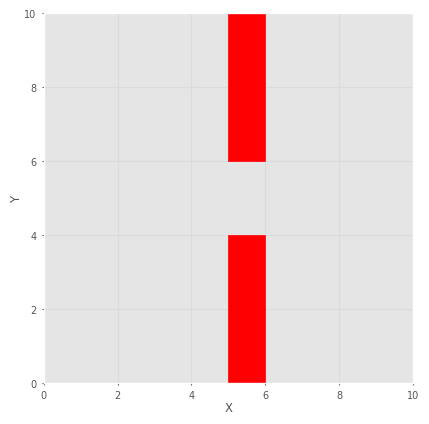

In [2]:
import math
import roboticstoolbox as rtb
import numpy as np

# start and goal configuration
qs = (2, 8, -math.pi/2)
qg = (8, 2, -math.pi/2)

# obstacle map
map = rtb.PolygonMap(workspace=[0, 10])
map.add([(5, 50), (5, 6), (6, 6), (6, 50)])
# map.add([(5, 0), (6, 0), (6, 4), (5, 4)])
map.add([(5, 4), (5, -50), (6, -50), (6, 4)])

map.plot(block=None)

l=3
w=1.5
piano = rtb.VehiclePolygon(np.array([(-l/2, w/2), (-l/2, -w/2), (l/2, -w/2), (l/2, w/2)]).T)

vehicle = rtb.Bicycle(steer_max=1, L=2, polygon=piano)
print(vehicle.curvature_max)

rrt = rtb.RRTPlanner(map=map, vehicle=vehicle, verbose=False, npoints=50, showsamples=True, seed=0)

rrt.plan(goal=qg)


In [ ]:
path, status = rrt.query(start=qs)
print(status)

map.plot(block=None)
rrt.g.plot(colorcomponents=False, text=False, force2d=True,
    vopt=dict(color='darkblue', marker='o', markersize=10), 
    eopt=dict(color='darkblue', linewidth=3), block=None)

rrt.plot(path)


In [ ]:
map.plot(block=None)
print(path.shape)
for i in range(0, 105, 10):
    vehicle._animation.plot(path[i,:], alpha=0.2)


In [ ]:
np.array([(-l/2, w/2), (-l/2, -w/2), (l/2, -w/2), (l/2, w/2)]).T


# Pose-graph optimization

In [ ]:
pg = rtb.PoseGraph('data/killian-small.toro')

pg.plot(text=False)


In [ ]:

pg.optimize()

pg.plot(text=False)


# Arm robotics

In [ ]:
from roboticstoolbox import models

panda = models.DH.Panda()

In [ ]:
panda

In [ ]:
tg = jtraj(panda.qz, panda.qr, 100)
print(tg)

In [ ]:
panda.plot(tg.q, backend="pyplot")

In [ ]:
from roboticstoolbox import models

panda = models.ETS.Panda()
panda

In [ ]:
panda.ets()

In [ ]:
q = panda.qr

panda.plot(q, backend="pyplot")

In [ ]:
panda.fkine(q)

In [ ]:
J = panda.jacob0(panda.qr)
J

In [ ]:
panda.manipulability(panda.qr)

In [ ]:
panda.jacobe(q)

In [ ]:
H = panda.hessian0(q)
H.shape

In [ ]:
panda.hasgeometry

In [ ]:
panda = models.URDF.Panda()
panda

In [ ]:
x=panda.links[2].geometry.data[0].filename
l2 = panda.links[2]
l2._I

In [ ]:
panda.hasgeometry


In [ ]:
panda.hasdynamics

In [ ]:
puma = models.DH.Puma560()
puma.hasdynamics

In [ ]:
puma.dynamics()

In [ ]:
q = puma.qn

puma.inertia(q)

In [ ]:
puma.gravload(q)

In [ ]:
puma.coriolis(q, [1, 0, 0, 0,0, 0])

In [ ]:
puma.inertia_x(q)

In [ ]:
puma.plot(q, backend="pyplot")
puma.fellipse(q)

In [ ]:
puma.gravload_x(q)